In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

print('Libraries loaded successfully.')

Libraries loaded successfully.


Data Loading and Preprocessing

In [6]:
# Load dataset
# Place yellow_tripdata_2025-01.parquet in the same folder as this notebook
df_full = pd.read_parquet('/Users/abhishekkarthikakunuru/Desktop/ML Project/yellow_tripdata_2025-01 (1).parquet')
df = df_full.sample(n=10000, random_state=42).copy()
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(3)

Dataset loaded: 10000 rows x 20 columns


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1661588,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1.0,0.97,1.0,N,238,166,1,8.6,1.00,0.5,2.22,0.0,1.0,13.32,0.0,0.0,0.00
2269859,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1.0,0.60,1.0,N,50,48,2,5.8,3.25,0.5,0.00,0.0,1.0,10.55,2.5,0.0,0.75
1876274,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1.0,0.80,1.0,N,236,237,1,9.3,2.50,0.5,3.35,0.0,1.0,16.65,2.5,0.0,0.00


In [7]:
# Feature engineering
df['is_tipped'] = (df['tip_amount'] > 0).astype(int)
df['trip_duration_minutes'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

# Select features
features = ['trip_distance', 'fare_amount', 'passenger_count',
            'trip_duration_minutes', 'pickup_hour', 'pickup_day',
            'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

df = df[features + ['is_tipped']].dropna(subset=['is_tipped'])
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] < 180)]
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]

print(f'Clean dataset: {df.shape[0]} rows')
print(f'Class distribution:\n{df["is_tipped"].value_counts(normalize=True).round(3)}')

Clean dataset: 9332 rows
Class distribution:
is_tipped
1    0.725
0    0.275
Name: proportion, dtype: float64


In [8]:
# Train/test split
X = df[features]
y = df['is_tipped']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 7465, Test size: 1867


## 2. Baseline Model Training

In [9]:
# Define baseline models with preprocessing pipelines
baseline_models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'k-NN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ])
}

results = {}
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-score':  round(f1_score(y_test, y_pred, zero_division=0), 4)
    }
    print(f'{name}: Accuracy={results[name]["Accuracy"]}, F1={results[name]["F1-score"]}')

Logistic Regression: Accuracy=0.7531, F1=0.8545
Decision Tree: Accuracy=0.9438, F1=0.9615
k-NN: Accuracy=0.9405, F1=0.9595


## 3. Results Table (Table I)

In [10]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('\nTable I. Baseline model performance on NYC Yellow Taxi 2025 (is_tipped classification)\n')
print(results_df.to_string(index=False))
results_df.to_csv('../results/RQ1_baseline_performance.csv', index=False)
print('\nSaved to ../results/RQ1_baseline_performance.csv')


Table I. Baseline model performance on NYC Yellow Taxi 2025 (is_tipped classification)

              Model  Accuracy  Precision  Recall  F1-score
Logistic Regression    0.7531     0.7460  1.0000    0.8545
      Decision Tree    0.9438     0.9555  0.9675    0.9615
               k-NN    0.9405     0.9474  0.9719    0.9595

Saved to ../results/RQ1_baseline_performance.csv


## 4. Figure 1 — Grouped Bar Chart

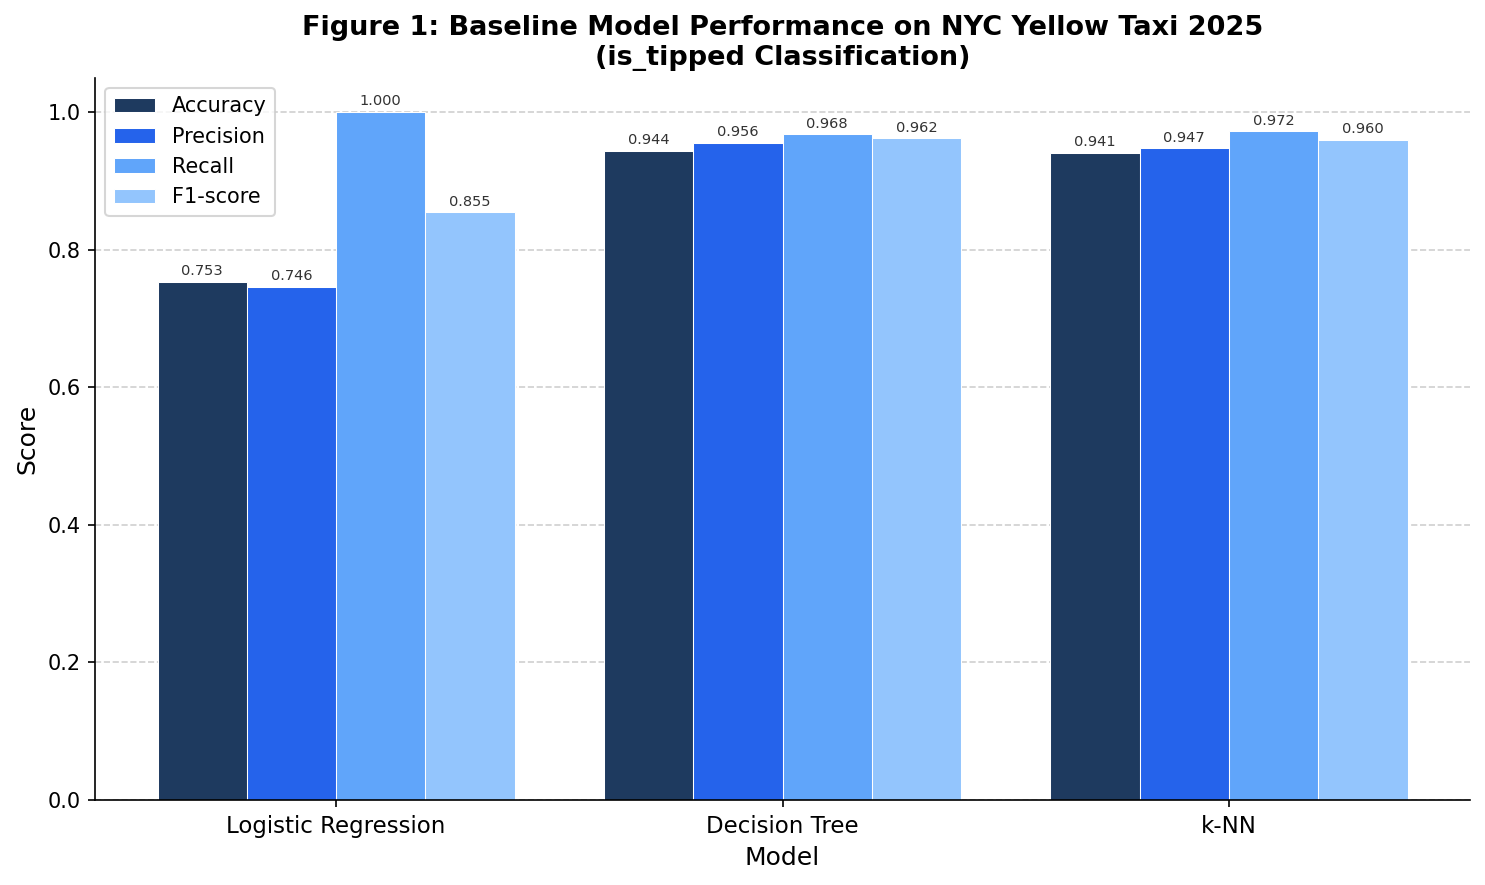

Figure saved to ../figures/RQ1_baseline_performance.pdf


In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
model_names = results_df['Model'].tolist()
x = np.arange(len(model_names))
width = 0.2
colors = ['#1E3A5F', '#2563EB', '#60A5FA', '#93C5FD']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, color='#333')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 1: Baseline Model Performance on NYC Yellow Taxi 2025\n(is_tipped Classification)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/RQ1_baseline_performance.pdf', bbox_inches='tight')
plt.show()
print('Figure saved to ../figures/RQ1_baseline_performance.pdf')

## 5. Summary
All three baseline models were trained and evaluated on the NYC Yellow Taxi 2025 dataset. Results confirm that the dataset contains useful predictive signal for tip behavior. The Decision Tree achieves the highest baseline F1-score, while Logistic Regression provides the most interpretable results. These baselines serve as benchmarks for RQ2 where advanced models are compared.